# Comparison with other databases
Compares Cultura with Cross-Verified, Pantheon 2.0 and three paper-only databases in size, overlap and coverage.

## Configuration

In [1]:
import tempfile
import duckdb
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from style import *

SEED = 42
DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
CROSS_VERIFIED_DB_PATH = '../data/similar_databases/cross_verified.duckdb'
PANTHEON_2_CSV_PATH = '../data/similar_databases/pantheon 2.0/person_2025_update.csv'

ADULT_ONSET_OFFSET = 30
CENTURY_MIN = -16
CENTURY_MAX = 19
SAMPLE_SIZE = 10
TOP_K_OCCUPATIONS = 10
CROSS_VERIFIED_SEVEN_LANGUAGES = ['en', 'fr', 'de', 'es', 'it', 'pt', 'sv']

apply_style()

def format_year_label(year):
    return f'{abs(year)} BCE' if year < 0 else f'{year}'

## External data — Cross-Verified, Pantheon 2.0, paper totals

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")
con.sql(f"ATTACH '{CROSS_VERIFIED_DB_PATH}' AS cv (READ_ONLY)")

con.sql("""
    CREATE TEMP TABLE cv_raw AS
    SELECT wikidata_code                       AS qid,
           name,
           birth,
           death,
           COALESCE(death, updated_death_date) AS death_or_updated,
           level1_main_occ,
           un_region,
           citizenship_1_b,
           list_wikipedia_editions
    FROM   cv.individuals
""")

con.sql("""
    CREATE TEMP TABLE cross_verified AS
    SELECT qid, name, birth, death, level1_main_occ, un_region, citizenship_1_b, list_wikipedia_editions,
           CASE
               WHEN birth IS NOT NULL AND death_or_updated IS NOT NULL
                   THEN CAST((birth + death_or_updated) / 2 AS BIGINT)
               WHEN birth IS NOT NULL THEN birth + $offset
               WHEN death_or_updated IS NOT NULL THEN death_or_updated - $offset
           END AS floruit_year
    FROM   cv_raw
""", params={'offset': ADULT_ONSET_OFFSET})

con.sql("""
    CREATE TEMP TABLE pantheon_2 AS
    SELECT wd_id AS qid, name, occupation, birthyear, deathyear, bplace_country, dplace_country, hpi,
           CASE
               WHEN birthyear IS NOT NULL AND deathyear IS NOT NULL
                   THEN CAST((birthyear + deathyear) / 2 AS BIGINT)
               WHEN birthyear IS NOT NULL THEN birthyear + $offset
               WHEN deathyear IS NOT NULL THEN deathyear - $offset
           END AS floruit_year
    FROM   read_csv_auto($path)
""", params={'offset': ADULT_ONSET_OFFSET, 'path': PANTHEON_2_CSV_PATH})

TABLE_STATS_SQL = """
    SELECT COUNT(*)            AS rows,
           COUNT(DISTINCT qid) AS distinct_qid,
           COUNT(floruit_year) AS with_year
    FROM   {table}
"""
print(con.sql(TABLE_STATS_SQL.format(table='cross_verified')).pl())
print(con.sql(TABLE_STATS_SQL.format(table='pantheon_2')).pl())
con.sql('SELECT qid, name, birth, death, level1_main_occ, un_region, floruit_year FROM cross_verified LIMIT 5').pl()

shape: (1, 3)
┌─────────┬──────────────┬───────────┐
│ rows    ┆ distinct_qid ┆ with_year │
│ ---     ┆ ---          ┆ ---       │
│ i64     ┆ i64          ┆ i64       │
╞═════════╪══════════════╪═══════════╡
│ 2291817 ┆ 2291817      ┆ 2141505   │
└─────────┴──────────────┴───────────┘
shape: (1, 3)
┌────────┬──────────────┬───────────┐
│ rows   ┆ distinct_qid ┆ with_year │
│ ---    ┆ ---          ┆ ---       │
│ i64    ┆ i64          ┆ i64       │
╞════════╪══════════════╪═══════════╡
│ 126582 ┆ 126582       ┆ 125324    │
└────────┴──────────────┴───────────┘


qid,name,birth,death,level1_main_occ,un_region,floruit_year
str,str,i64,i64,str,str,i64
"""Q1000002""","""Claus_Hammel""",1932,1990,"""Culture""","""Europe""",1961
"""Q1000005""","""Karel_Matěj_Čapek-Chod""",1860,1927,"""Culture""","""Europe""",1894
"""Q1000006""","""Florian_Eichinger""",1971,null,"""Culture""","""Europe""",2001
"""Q1000015""","""Florian_Jahr""",1983,null,"""Culture""","""Europe""",2013
"""Q1000023""","""Wiltraut_Rupp-von_Brünneck""",1912,1977,"""Leadership""","""Europe""",1944


In [3]:
HBR_TOTAL = 7_015_353
HBR_WITH_COUNTRY = round(HBR_TOTAL * 0.7759)
HBR_WITH_BIRTH = round(HBR_TOTAL * 0.6043)
HBR_WITH_OCCUPATION = round(HBR_TOTAL * 0.7590)

SCHICH_FB_TOTAL = 120_211

CHANEY_TOTAL = 537_247
CHANEY_WITH_REGION = 486_179
CHANEY_WITH_DATES = 537_247
CHANEY_WITH_OCCUPATION = 537_247

## Load Cultura data

In [4]:
con.sql("""
    CREATE TEMP TABLE cultura AS
    SELECT    i.entity.qid                               AS qid,
              i.entity.label_en                          AS name_en,
              e.peak_productivity.start_year             AS floruit_year,
              e.polity_count > 0                         AS has_polity,
              len(i.occupation) > 0                      AS has_occupation,
              i.entity.qid IN (SELECT qid FROM cross_verified) AS in_cross_verified,
              i.entity.qid IN (SELECT qid FROM pantheon_2)     AS in_pantheon_2
    FROM      individual AS i
    LEFT JOIN individual_enriched AS e ON e.entity.qid = i.entity.qid
""")
cultura_stats = con.sql("""
    SELECT COUNT(*)                                  AS individuals,
           COUNT(DISTINCT qid)                       AS distinct_qid,
           COUNT(floruit_year)                       AS with_floruit,
           COUNT(*) FILTER (WHERE in_cross_verified) AS in_cross_verified,
           COUNT(*) FILTER (WHERE in_pantheon_2)     AS in_pantheon_2
    FROM   cultura
""").pl()
assert cultura_stats['individuals'][0] == cultura_stats['distinct_qid'][0]
print(cultura_stats)
con.sql('SELECT * FROM cultura WHERE floruit_year IS NOT NULL LIMIT 5').pl()

shape: (1, 5)
┌─────────────┬──────────────┬──────────────┬───────────────────┬───────────────┐
│ individuals ┆ distinct_qid ┆ with_floruit ┆ in_cross_verified ┆ in_pantheon_2 │
│ ---         ┆ ---          ┆ ---          ┆ ---               ┆ ---           │
│ i64         ┆ i64          ┆ i64          ┆ i64               ┆ i64           │
╞═════════════╪══════════════╪══════════════╪═══════════════════╪═══════════════╡
│ 13002897    ┆ 13002897     ┆ 9709528      ┆ 2271587           ┆ 125337        │
└─────────────┴──────────────┴──────────────┴───────────────────┴───────────────┘


qid,name_en,floruit_year,has_polity,has_occupation,in_cross_verified,in_pantheon_2
str,str,i64,bool,bool,bool,bool
"""Q103000549""","""GÃ¶ran Otto Wallencreutz""",1776,true,false,false,false
"""Q103000749""","""Karim Ghanes""",2016,null,false,false,false
"""Q103002446""","""Jeffrey Watt""",1990,null,false,false,false
"""Q103002856""","""Justine Dattani""",2017,null,false,false,false
"""Q103002891""","""Florian Bourse""",2020,null,false,false,false


### Western / non-Western flags

In [5]:
con.sql("""
    CREATE TEMP TABLE wikipedia_language AS
    SELECT regexp_extract(url, '^https://([^.]+)\\.wikipedia\\.org$', 1) AS language,
           url,
           is_western
    FROM   sitelink
    WHERE  url LIKE '%.wikipedia.org'
""")
con.register('cv_seven', pl.DataFrame({'language': CROSS_VERIFIED_SEVEN_LANGUAGES}))
con.sql("""
    CREATE TEMP TABLE wikipedia_flags AS
    SELECT   s.qid,
             bool_or(w.language IN (SELECT language FROM cv_seven)) AS has_cv_seven_edition,
             bool_or(w.is_western)                                  AS has_western_wikipedia,
             bool_or(NOT w.is_western)                              AS has_non_western_wikipedia
    FROM     individual_sitelink AS s
    JOIN     wikipedia_language AS w ON w.url = s.site_url
    GROUP BY s.qid
""")
print(con.sql('SELECT COUNT(*) AS individuals_with_wikipedia FROM wikipedia_flags').pl())
con.sql('SELECT * FROM wikipedia_flags LIMIT 5').pl()

shape: (1, 1)
┌────────────────────────────┐
│ individuals_with_wikipedia │
│ ---                        │
│ i64                        │
╞════════════════════════════╡
│ 4743973                    │
└────────────────────────────┘


qid,has_cv_seven_edition,has_western_wikipedia,has_non_western_wikipedia
str,bool,bool,bool
"""Q105110923""",true,true,false
"""Q105113814""",false,true,false
"""Q1051160""",true,true,true
"""Q105119504""",true,true,true
"""Q10511977""",true,true,true


In [6]:
con.sql("""
    CREATE TEMP TABLE place_resolved_state AS
    SELECT    p.entity.qid AS qid,
              CASE WHEN p.present_day_state.name IS NOT NULL
                   THEN p.present_day_state
                   ELSE country.present_day_state
              END AS state
    FROM      place AS p
    LEFT JOIN place AS country ON country.entity.qid = p.country.qid
""")

catalog_categories = con.sql("""
    SELECT    i.property.pid        AS pid,
              i.issuer_country.name AS country_qid,
              s.state.is_western    AS is_western
    FROM      identifier AS i
    LEFT JOIN place_resolved_state AS s ON s.qid = i.issuer_country.name
    WHERE     i.issuer_country.name IS NOT NULL
""").pl().with_columns(
    pl.when(pl.col('country_qid') == 'Q1072012').then(pl.lit('international'))
    .when(pl.col('is_western')).then(pl.lit('western'))
    .when(~pl.col('is_western')).then(pl.lit('non_western'))
    .alias('category')
)
assert catalog_categories['pid'].is_unique().all()
con.register('catalog_categories', catalog_categories.filter(pl.col('category').is_not_null()))
print(catalog_categories.group_by('category').len())

con.sql("""
    CREATE TEMP TABLE catalog_flags AS
    SELECT   ii.qid,
             bool_or(c.category = 'western')       AS has_western_catalog,
             bool_or(c.category = 'non_western')   AS has_non_western_catalog,
             bool_or(c.category = 'international') AS has_international_catalog
    FROM     individual_identifier AS ii
    JOIN     catalog_categories AS c USING (pid)
    GROUP BY ii.qid
""")
con.sql('SELECT * FROM catalog_flags LIMIT 5').pl()

shape: (4, 2)
┌───────────────┬──────┐
│ category      ┆ len  │
│ ---           ┆ ---  │
│ str           ┆ u32  │
╞═══════════════╪══════╡
│ null          ┆ 28   │
│ international ┆ 1    │
│ western       ┆ 1013 │
│ non_western   ┆ 393  │
└───────────────┴──────┘


qid,has_western_catalog,has_non_western_catalog,has_international_catalog
str,bool,bool,bool
"""Q101224446""",true,false,false
"""Q101225498""",true,false,false
"""Q101231397""",true,false,false
"""Q101235889""",false,true,false
"""Q101237596""",true,false,true


## Preprocessing

### Database sizes and overlap

In [7]:
cultura_overlap = con.sql("""
    SELECT COUNT(*)                                  AS cultura,
           COUNT(*) FILTER (WHERE in_cross_verified) AS cultura_and_cv,
           COUNT(*) FILTER (WHERE in_pantheon_2)     AS cultura_and_pantheon
    FROM   cultura
""").pl().row(0, named=True)

cross_verified_size = con.sql("""
    SELECT COUNT(*)            AS cross_verified_rows,
           COUNT(DISTINCT qid) AS cross_verified
    FROM   cross_verified
""").pl().row(0, named=True)

pantheon_2_size = con.sql("""
    SELECT COUNT(*)            AS pantheon_2_rows,
           COUNT(DISTINCT qid) AS pantheon_2
    FROM   pantheon_2
""").pl().row(0, named=True)

overlap = {**cultura_overlap, **cross_verified_size, **pantheon_2_size}

database_sizes = pl.DataFrame({
    'database': ['Cultura', 'Cross-Verified', 'Pantheon 2.0'],
    'individuals': [overlap['cultura'], overlap['cross_verified_rows'], overlap['pantheon_2_rows']],
})
database_sizes

database,individuals
str,i64
"""Cultura""",13002897
"""Cross-Verified""",2291817
"""Pantheon 2.0""",126582


In [8]:
overlap_summary = pl.DataFrame({
    'set': ['Cultura', 'Cross-Verified', 'Pantheon 2.0', 'Cultura ∩ Cross-Verified', 'Cultura ∩ Pantheon 2.0',
            'Cross-Verified only (not in Cultura)', 'Pantheon 2.0 only (not in Cultura)'],
    'individuals': [overlap['cultura'], overlap['cross_verified'], overlap['pantheon_2'],
                    overlap['cultura_and_cv'], overlap['cultura_and_pantheon'],
                    overlap['cross_verified'] - overlap['cultura_and_cv'],
                    overlap['pantheon_2'] - overlap['cultura_and_pantheon']],
})
overlap_summary

set,individuals
str,i64
"""Cultura""",13002897
"""Cross-Verified""",2291817
"""Pantheon 2.0""",126582
"""Cultura ∩ Cross-Verified""",2271587
"""Cultura ∩ Pantheon 2.0""",125337
"""Cross-Verified only (not in Cu…",20230
"""Pantheon 2.0 only (not in Cult…",1245


### Coverage of reference databases

In [9]:
coverage_by_db = pl.DataFrame({
    'database': ['Cross-Verified', 'Pantheon 2.0'],
    'in_cultura': [overlap['cultura_and_cv'], overlap['cultura_and_pantheon']],
    'not_in_cultura': [overlap['cross_verified'] - overlap['cultura_and_cv'],
                       overlap['pantheon_2'] - overlap['cultura_and_pantheon']],
}).with_columns(
    (pl.col('in_cultura') / (pl.col('in_cultura') + pl.col('not_in_cultura')) * 100).round(2).alias('share_in_cultura_pct')
)
coverage_by_db

database,in_cultura,not_in_cultura,share_in_cultura_pct
str,i64,i64,f64
"""Cross-Verified""",2271587,20230,99.12
"""Pantheon 2.0""",125337,1245,99.02


### Per-century counts

In [10]:
centuries = np.arange(CENTURY_MIN, CENTURY_MAX + 1)

def per_century(table):
    df = con.sql(f"""
        SELECT   CAST(floor(floruit_year / 100) AS BIGINT) AS century,
                 COUNT(*)                                  AS n
        FROM     {table}
        WHERE    floruit_year IS NOT NULL
        GROUP BY century
    """).pl()
    lookup = dict(zip(df['century'].to_list(), df['n'].to_list()))
    return [lookup.get(int(c), 0) for c in centuries]

per_century_counts = pl.DataFrame({
    'century': centuries,
    'cultura': per_century('cultura'),
    'cross_verified': per_century('cross_verified'),
    'pantheon_2': per_century('pantheon_2'),
})
per_century_share = per_century_counts.with_columns(
    (pl.col(c) / pl.col(c).sum() * 100).alias(f'{c}_share_pct') for c in ['cultura', 'cross_verified', 'pantheon_2']
)
assert per_century_counts['century'].is_unique().all()
per_century_share.tail()

century,cultura,cross_verified,pantheon_2,cultura_share_pct,cross_verified_share_pct,pantheon_2_share_pct
i64,i64,i64,i64,f64,f64,f64
15,96242,25325,1738,1.60459,1.549164,2.2418
16,171836,37069,1809,2.864928,2.26756,2.333381
17,288370,63936,2679,4.807836,3.91105,3.45557
18,961396,237835,8421,16.028831,14.548681,10.862022
19,4283843,1216389,52642,71.422179,74.408122,67.901505


### Cross-Verified missing from Cultura

In [11]:
con.sql("""
    CREATE TEMP TABLE cv_only AS
    SELECT *
    FROM   cross_verified
    WHERE  qid IS NOT NULL
      AND  qid NOT IN (SELECT qid FROM cultura)
""")
print(f"CV-only individuals: {con.sql('SELECT COUNT(*) FROM cv_only').fetchone()[0]:,}")
cv_only_top_occupations = con.sql("""
    SELECT   COALESCE(level1_main_occ, '(unknown)') AS level1_main_occ,
             COUNT(*)                               AS individuals
    FROM     cv_only
    GROUP BY 1
    ORDER BY individuals DESC
    LIMIT    $top_k
""", params={'top_k': TOP_K_OCCUPATIONS}).pl()
cv_only_top_occupations

CV-only individuals: 20,230


level1_main_occ,individuals
str,i64
"""Leadership""",6429
"""Culture""",5747
"""Sports/Games""",4494
"""Discovery/Science""",2455
"""Other""",724
"""Missing""",381


### Random samples

In [12]:
cv_only_sample = con.sql(f"""
    SELECT qid, name, birth, death, level1_main_occ, un_region
    FROM   cv_only
    USING  SAMPLE reservoir({SAMPLE_SIZE} ROWS) REPEATABLE ({SEED})
""").pl().sort('birth')
cv_only_sample

qid,name,birth,death,level1_main_occ,un_region
str,str,i64,i64,str,str
"""Q5991322""","""Iftikhar_Zafar""",null,null,"""Culture""","""Asia"""
"""Q55641791""","""Sophia_of_Saxony""",null,1244,"""Leadership""","""Europe"""
"""Q16204022""","""Ignatius_Jacob_I""",null,1517,"""Culture""","""Asia"""
"""Q4236490""","""Johann_Friedrich_Wilhelm_Koch""",1759,1831,"""Discovery/Science""","""Europe"""
"""Q38773254""","""Werner_Sundblad""",1877,1909,"""Culture""","""Europe"""
"""Q5660345""","""Harold_Cooke""",1907,1986,"""Sports/Games""","""Europe"""
"""Q9777656""","""Clovis_Sperb_de_Barcellos""",1943,null,"""Other""","""America"""
"""Q28935824""","""Verica_Barać""",1955,2012,"""Leadership""","""Europe"""
"""Q23799187""","""Durgham_Maraee""",1971,null,"""Leadership""","""Asia"""


In [13]:
cultura_only_sample = con.sql(f"""
    SELECT qid, name_en, floruit_year
    FROM   (SELECT * FROM cultura WHERE NOT in_cross_verified AND floruit_year IS NOT NULL)
    USING  SAMPLE reservoir({SAMPLE_SIZE} ROWS) REPEATABLE ({SEED})
""").pl().sort('floruit_year')
cultura_only_sample

qid,name_en,floruit_year
str,str,i64
"""Q11562559""","""Watanabe Noritsuna""",1785
"""Q109011949""","""AdÃ©laide-Sophie BarrÃ©""",1804
"""Q105357035""","""Yevdokiya Tolstaya""",1824
"""Q105354127""","""Clara Zallow""",1901
"""Q102046773""","""Grace Helen Bailey""",1905
"""Q108920076""","""Walter Demal""",1931
"""Q106819644""","""Viktor Israel Bienenfeld""",1931
"""Q112350461""",null,1962
"""Q112356268""","""Werner Kraus""",1984


### Counts — Cultura

In [14]:
cultura_fields = con.sql("""
    SELECT COUNT(*)                                       AS total,
           COUNT(*) FILTER (WHERE has_polity)             AS with_polity,
           COUNT(*) FILTER (WHERE floruit_year IS NOT NULL) AS with_floruit,
           COUNT(*) FILTER (WHERE has_occupation)         AS with_occupation
    FROM   cultura
""").pl().row(0, named=True)

cultura_wikipedia = con.sql("""
    SELECT COUNT(*) FILTER (WHERE has_cv_seven_edition)     AS in_cv_seven,
           COUNT(*) FILTER (WHERE NOT has_cv_seven_edition) AS outside_cv_seven,
           COUNT(*) FILTER (WHERE has_non_western_wikipedia
                              AND NOT COALESCE(has_western_wikipedia, false)) AS nw_wikipedia_only
    FROM   wikipedia_flags
""").pl().row(0, named=True)

cultura_catalogs = con.sql("""
    SELECT COUNT(*) FILTER (WHERE has_non_western_catalog AND NOT has_western_catalog) AS nw_catalog_only
    FROM   catalog_flags
""").pl().row(0, named=True)

cultura_counts = {**cultura_fields, **cultura_wikipedia, **cultura_catalogs}
pl.DataFrame({'metric': list(cultura_counts), 'individuals': list(cultura_counts.values())})

metric,individuals
str,i64
"""total""",13002897
"""with_polity""",5158972
"""with_floruit""",9709528
"""with_occupation""",9038108
"""in_cv_seven""",3161340
"""outside_cv_seven""",1582633
"""nw_wikipedia_only""",938946
"""nw_catalog_only""",251205


### Counts — Cross-Verified

In [15]:
con.sql("""
    CREATE TEMP TABLE cv_editions AS
    SELECT qid,
           regexp_replace(unnest(string_split(list_wikipedia_editions, '|')), 'wiki$', '') AS language
    FROM   cross_verified
    WHERE  list_wikipedia_editions IS NOT NULL
      AND  list_wikipedia_editions != ''
""")

con.sql("""
    CREATE TEMP TABLE cv_wikipedia_flags AS
    SELECT    e.qid,
              bool_or(e.language IN (SELECT language FROM cv_seven)) AS in_seven,
              COALESCE(bool_or(w.is_western), false)                 AS has_western,
              COALESCE(bool_or(NOT w.is_western), false)             AS has_non_western
    FROM      cv_editions AS e
    LEFT JOIN wikipedia_language AS w USING (language)
    GROUP BY  e.qid
""")

cv_fields = con.sql("""
    SELECT COUNT(*)                                                    AS total,
           COUNT(*) FILTER (WHERE citizenship_1_b IS NOT NULL)         AS with_citizenship,
           COUNT(*) FILTER (WHERE birth IS NOT NULL OR death IS NOT NULL) AS with_dates,
           COUNT(*) FILTER (WHERE level1_main_occ IS NOT NULL
                              AND level1_main_occ != 'Missing')        AS with_occupation
    FROM   cross_verified
""").pl().row(0, named=True)

cv_wikipedia = con.sql("""
    SELECT COUNT(*) FILTER (WHERE in_seven)                         AS in_cv_seven,
           COUNT(*) FILTER (WHERE NOT in_seven)                     AS outside_cv_seven,
           COUNT(*) FILTER (WHERE has_non_western AND NOT has_western) AS nw_wikipedia_only
    FROM   cv_wikipedia_flags
""").pl().row(0, named=True)

cv_counts = {**cv_fields, **cv_wikipedia}
pl.DataFrame({'metric': list(cv_counts), 'individuals': list(cv_counts.values())})

metric,individuals
str,i64
"""total""",2291817
"""with_citizenship""",2238318
"""with_dates""",2140640
"""with_occupation""",2276400
"""in_cv_seven""",2290997
"""outside_cv_seven""",820
"""nw_wikipedia_only""",169


### Counts — Pantheon 2.0

In [16]:
pantheon_2_counts = con.sql("""
    SELECT COUNT(*)                                                                 AS total,
           COUNT(*) FILTER (WHERE bplace_country IS NOT NULL OR dplace_country IS NOT NULL) AS with_country,
           COUNT(*) FILTER (WHERE birthyear IS NOT NULL OR deathyear IS NOT NULL)   AS with_dates,
           COUNT(occupation)                                                        AS with_occupation
    FROM   pantheon_2
""").pl().row(0, named=True)
pl.DataFrame({'metric': list(pantheon_2_counts), 'individuals': list(pantheon_2_counts.values())})

metric,individuals
str,i64
"""total""",126582
"""with_country""",123104
"""with_dates""",125324
"""with_occupation""",126520


## Figures and tables

### Fig 1 — Individuals per century

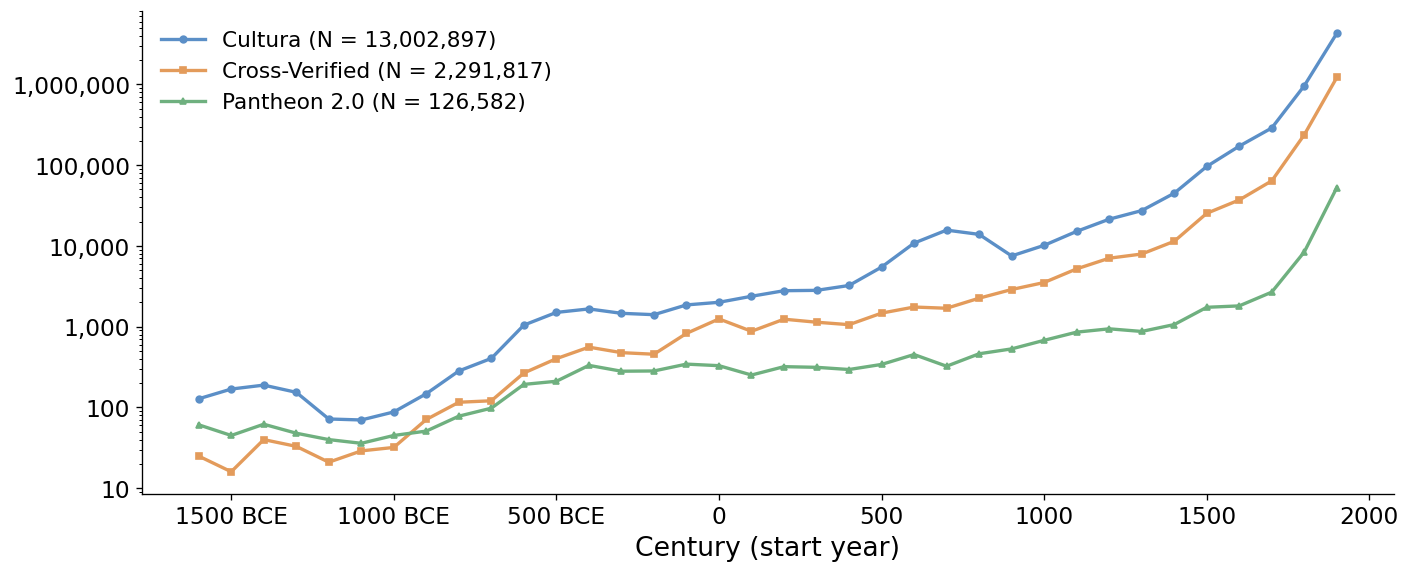

In [17]:
century_x = centuries * 100
series = [
    ('cultura', 'Cultura', 'o', overlap['cultura']),
    ('cross_verified', 'Cross-Verified', 's', overlap['cross_verified_rows']),
    ('pantheon_2', 'Pantheon 2.0', '^', overlap['pantheon_2_rows']),
]
year_ticks = np.arange(-1500, 2001, 500)

fig, ax = plt.subplots()
for key, label, marker, total in series:
    ax.plot(century_x, per_century_counts[key], color=DATABASE_COLORS[key], marker=marker, ms=4,
            label=f'{label} (N = {total:,})')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(THOUSANDS)
ax.set_xticks(year_ticks)
ax.set_xticklabels([format_year_label(int(t)) for t in year_ticks])
ax.set_xlabel('Century (start year)')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

### Fig 2 — Share per century

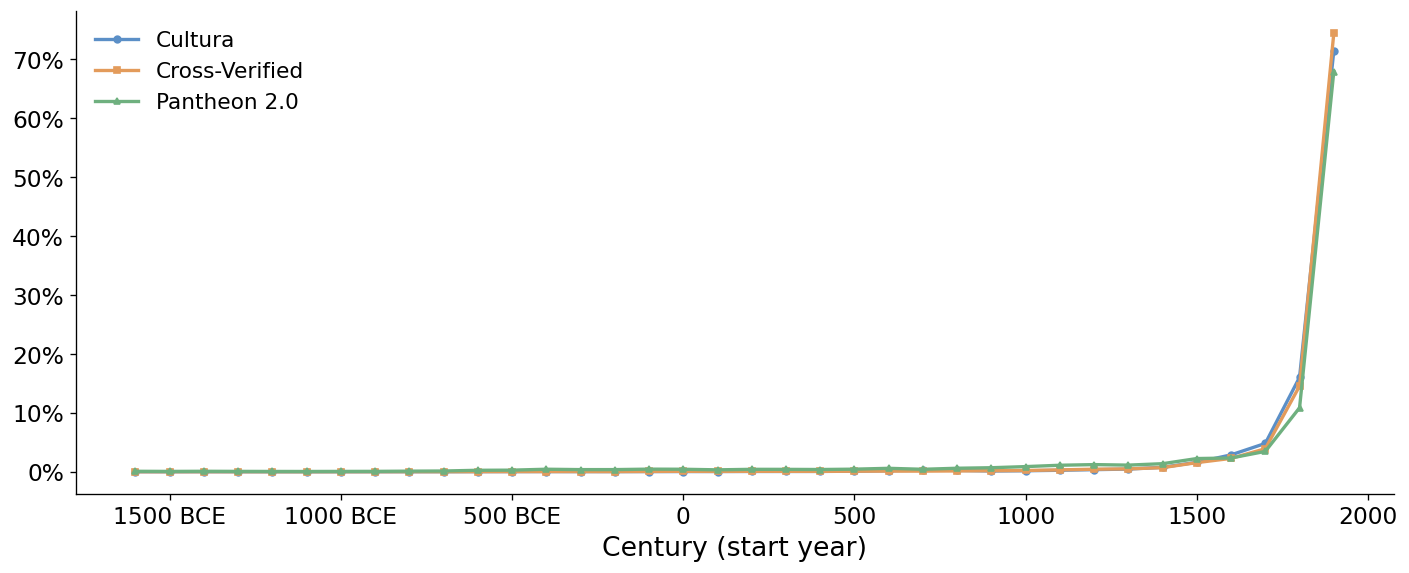

In [18]:
fig, ax = plt.subplots()
for key, label, marker, _ in series:
    ax.plot(century_x, per_century_share[f'{key}_share_pct'], color=DATABASE_COLORS[key], marker=marker, ms=4, label=label)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xticks(year_ticks)
ax.set_xticklabels([format_year_label(int(t)) for t in year_ticks])
ax.set_xlabel('Century (start year)')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

### Table 1 — Database comparison

In [19]:
DASH = '—'
comparison_rows = [
    ('Total individuals', cultura_counts['total'], cv_counts['total'], pantheon_2_counts['total'],
     HBR_TOTAL, SCHICH_FB_TOTAL, CHANEY_TOTAL),
    ('With polity / citizenship', cultura_counts['with_polity'], cv_counts['with_citizenship'],
     pantheon_2_counts['with_country'], HBR_WITH_COUNTRY, DASH, CHANEY_WITH_REGION),
    ('With floruit / birth-or-death date', cultura_counts['with_floruit'], cv_counts['with_dates'],
     pantheon_2_counts['with_dates'], HBR_WITH_BIRTH, SCHICH_FB_TOTAL, CHANEY_WITH_DATES),
    ('With occupation', cultura_counts['with_occupation'], cv_counts['with_occupation'],
     pantheon_2_counts['with_occupation'], HBR_WITH_OCCUPATION, DASH, CHANEY_WITH_OCCUPATION),
    ('In any of the seven main CV Wikipedia editions', cultura_counts['in_cv_seven'], cv_counts['in_cv_seven'],
     DASH, DASH, DASH, DASH),
    ('In Wikipedia outside the seven main CV editions', cultura_counts['outside_cv_seven'], cv_counts['outside_cv_seven'],
     DASH, DASH, DASH, DASH),
    ('Only in non-Western Wikipedia', cultura_counts['nw_wikipedia_only'], cv_counts['nw_wikipedia_only'],
     DASH, DASH, DASH, DASH),
    ('Only in non-Western catalogs', cultura_counts['nw_catalog_only'], DASH, DASH, DASH, DASH, DASH),
]

def format_value(value):
    return f'{value:,}' if isinstance(value, (int, np.integer)) else value

comparison_table = pl.DataFrame(
    [[r[0]] + [format_value(v) for v in r[1:]] for r in comparison_rows],
    schema=['dimension', 'cultura', 'cross_verified', 'pantheon_2', 'hbr', 'schich_2014', 'chaney_2024'],
    orient='row',
)
with pl.Config(tbl_cols=-1, tbl_width_chars=220, fmt_str_lengths=60, tbl_rows=20):
    print(comparison_table)

shape: (8, 7)
┌─────────────────────────────────────────────────┬────────────┬────────────────┬────────────┬───────────┬─────────────┬─────────────┐
│ dimension                                       ┆ cultura    ┆ cross_verified ┆ pantheon_2 ┆ hbr       ┆ schich_2014 ┆ chaney_2024 │
│ ---                                             ┆ ---        ┆ ---            ┆ ---        ┆ ---       ┆ ---         ┆ ---         │
│ str                                             ┆ str        ┆ str            ┆ str        ┆ str       ┆ str         ┆ str         │
╞═════════════════════════════════════════════════╪════════════╪════════════════╪════════════╪═══════════╪═════════════╪═════════════╡
│ Total individuals                               ┆ 13,002,897 ┆ 2,291,817      ┆ 126,582    ┆ 7,015,353 ┆ 120,211     ┆ 537,247     │
│ With polity / citizenship                       ┆ 5,158,972  ┆ 2,238,318      ┆ 123,104    ┆ 5,443,212 ┆ —           ┆ 486,179     │
│ With floruit / birth-or-death date     

In [20]:
con.close()